# Notebook 2 - Exploratory Data Analysis (EDA)

**Project phase:** Formula 1 Big Data Analysis with PySpark  
**Spark components:** PySpark DataFrame API  
**Goal:** Explore historical Formula 1 data using the PySpark DataFrame API, perform exploratory data analysis with visualizations, and create driver career flow diagrams to investigate team transitions, career trajectories, and performance trends across seasons.

## 1. Spark session & gold tables

In [6]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from google.colab import drive
import os

drive.mount('/content/drive')

spark = (
    SparkSession.builder
    .appName("F1 Notebook 2b - EDA")
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

DATASET_PATH = "/content/drive/MyDrive/data_analysis"
SILVER_PATH = f"{DATASET_PATH}/lakehouse/silver"
GOLD_PATH = f"{DATASET_PATH}/lakehouse/gold"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !apt-get install -y graphviz

In [10]:
silver = {}

for table_name in os.listdir(SILVER_PATH):
    table_path = f"{SILVER_PATH}/{table_name}"

    if os.path.isdir(table_path):
        silver[table_name] = spark.read.parquet(table_path)

## General overview of all tables
*   number of rows
*   number of columns
*   data types
*   example records

In [8]:
for name, df in silver.items():
    print(f"\n{name}")
    print(f"Rows: {df.count()}")
    print(f"Columns: {len(df.columns)}")
    df.printSchema()


races
Rows: 1125
Columns: 8
root
 |-- raceId: integer (nullable = true)
 |-- round: integer (nullable = true)
 |-- circuitId: integer (nullable = true)
 |-- race_name: string (nullable = true)
 |-- date: date (nullable = true)
 |-- ingested_at: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- year: integer (nullable = true)


drivers
Rows: 861
Columns: 12
root
 |-- driverId: integer (nullable = true)
 |-- driverRef: string (nullable = true)
 |-- number: integer (nullable = true)
 |-- code: string (nullable = true)
 |-- forename: string (nullable = true)
 |-- surname: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- nationality: string (nullable = true)
 |-- url: string (nullable = true)
 |-- ingested_at: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- driver_name: string (nullable = true)


constructors
Rows: 212
Columns: 7
root
 |-- constructorId: integer (nullable = true)
 |-- constructorRef: string (nullable = tru

In [9]:
for name, df in silver.items():
    print(f"\n{name}")
    df.show(5)


races
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
|raceId|round|circuitId|           race_name|      date|         ingested_at|source_file|year|
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
|  1121|    1|        3|  Bahrain Grand Prix|2024-03-02|2026-05-29 20:12:...|  races.csv|2024|
|  1122|    2|       77|Saudi Arabian Gra...|2024-03-09|2026-05-29 20:12:...|  races.csv|2024|
|  1123|    3|        1|Australian Grand ...|2024-03-24|2026-05-29 20:12:...|  races.csv|2024|
|  1124|    4|       22| Japanese Grand Prix|2024-04-07|2026-05-29 20:12:...|  races.csv|2024|
|  1125|    5|       17|  Chinese Grand Prix|2024-04-21|2026-05-29 20:12:...|  races.csv|2024|
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
only showing top 5 rows

drivers
+--------+----------+------+----+--------+----------+----------+-----------+--------------------+--------

### Structural and Logical Data Validation

Before going deeper into the analysis, we check the quality of the data.

We look for:
- duplicate primary keys,
- broken links between tables (foreign keys),
- impossible numeric values,
- invalid map coordinates,
- and other logical errors.

All checks use PySpark aggregations and joins, so they also work well on large datasets.

In [11]:
from pyspark.sql import functions as F

# ============================================================
# Assign tables from silver layer
# ============================================================

races = silver["races"]
drivers = silver["drivers"]
constructors = silver["constructors"]
circuits = silver["circuits"]
status = silver["status"]

results = silver["results"]
qualifying = silver["qualifying"]
lap_times = silver["lap_times"]
pit_stops = silver["pit_stops"]

driver_standings = silver["driver_standings"]
constructor_standings = silver["constructor_standings"]
constructor_results = silver["constructor_results"]

if "sprint_results" in silver:
    sprint_results = silver["sprint_results"]

# ============================================================
# Scalable Data Validation Helpers
# ============================================================

def show_duplicate_keys(df, key_cols, table_name):
    print(f"\nDuplicate key check: {table_name}")

    duplicates = (
        df.groupBy(*key_cols)
          .agg(F.count("*").alias("record_count"))
          .filter(F.col("record_count") > 1)
    )

    duplicates.show(20, truncate=False)


def show_invalid_value_summary(df, conditions, table_name):
    print(f"\nInvalid value summary: {table_name}")

    summary = df.agg(*[
        F.sum(F.when(condition, 1).otherwise(0)).alias(check_name)
        for check_name, condition in conditions.items()
    ])

    summary.show(truncate=False)


def show_foreign_key_violations(child_df, parent_df, child_key, parent_key, child_name, parent_name):
    print(f"\nForeign key check: {child_name}.{child_key} -> {parent_name}.{parent_key}")

    missing_refs = (
        child_df.select(child_key).distinct()
        .join(
            parent_df.select(parent_key).distinct(),
            child_df[child_key] == parent_df[parent_key],
            "left_anti"
        )
    )

    missing_refs.show(20, truncate=False)


# ============================================================
# 1. Duplicate Key Checks
# ============================================================

show_duplicate_keys(races, ["raceId"], "races")
show_duplicate_keys(drivers, ["driverId"], "drivers")
show_duplicate_keys(constructors, ["constructorId"], "constructors")
show_duplicate_keys(circuits, ["circuitId"], "circuits")
show_duplicate_keys(status, ["statusId"], "status")

show_duplicate_keys(results, ["resultId"], "results")
show_duplicate_keys(qualifying, ["qualifyId"], "qualifying")
show_duplicate_keys(driver_standings, ["driverStandingsId"], "driver_standings")
show_duplicate_keys(constructor_standings, ["constructorStandingsId"], "constructor_standings")
show_duplicate_keys(constructor_results, ["constructorResultsId"], "constructor_results")

if "sprint_results" in globals():
    show_duplicate_keys(sprint_results, ["resultId"], "sprint_results")


# ============================================================
# 2. Foreign Key Integrity Checks
# ============================================================

show_foreign_key_violations(results, races, "raceId", "raceId", "results", "races")
show_foreign_key_violations(results, drivers, "driverId", "driverId", "results", "drivers")
show_foreign_key_violations(results, constructors, "constructorId", "constructorId", "results", "constructors")
show_foreign_key_violations(results, status, "statusId", "statusId", "results", "status")

show_foreign_key_violations(races, circuits, "circuitId", "circuitId", "races", "circuits")

show_foreign_key_violations(qualifying, races, "raceId", "raceId", "qualifying", "races")
show_foreign_key_violations(qualifying, drivers, "driverId", "driverId", "qualifying", "drivers")
show_foreign_key_violations(qualifying, constructors, "constructorId", "constructorId", "qualifying", "constructors")

show_foreign_key_violations(driver_standings, races, "raceId", "raceId", "driver_standings", "races")
show_foreign_key_violations(driver_standings, drivers, "driverId", "driverId", "driver_standings", "drivers")

show_foreign_key_violations(constructor_standings, races, "raceId", "raceId", "constructor_standings", "races")
show_foreign_key_violations(constructor_standings, constructors, "constructorId", "constructorId", "constructor_standings", "constructors")

show_foreign_key_violations(constructor_results, races, "raceId", "raceId", "constructor_results", "races")
show_foreign_key_violations(constructor_results, constructors, "constructorId", "constructorId", "constructor_results", "constructors")

if "sprint_results" in globals():
    show_foreign_key_violations(sprint_results, races, "raceId", "raceId", "sprint_results", "races")
    show_foreign_key_violations(sprint_results, drivers, "driverId", "driverId", "sprint_results", "drivers")
    show_foreign_key_violations(sprint_results, constructors, "constructorId", "constructorId", "sprint_results", "constructors")
    show_foreign_key_violations(sprint_results, status, "statusId", "statusId", "sprint_results", "status")


# ============================================================
# 3. Range and Logical Consistency Checks
# ============================================================

show_invalid_value_summary(
    races,
    {
        "year_before_1950": F.col("year") < 1950,
        "round_less_than_1": F.col("round") < 1,
        "missing_date": F.col("date").isNull()
    },
    "races"
)

show_invalid_value_summary(
    circuits,
    {
        "invalid_latitude": (F.col("lat") < -90) | (F.col("lat") > 90),
        "invalid_longitude": (F.col("lng") < -180) | (F.col("lng") > 180),
        "missing_latitude": F.col("lat").isNull(),
        "missing_longitude": F.col("lng").isNull()
    },
    "circuits"
)

show_invalid_value_summary(
    results,
    {
        "negative_grid": F.col("grid") < 0,
        "negative_position_order": F.col("positionOrder") < 0,
        "negative_points": F.col("points") < 0,
        "negative_laps": F.col("laps") < 0,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_fastest_lap_speed": F.col("fastestLapSpeed") < 0,
        "zero_fastest_lap_speed": F.col("fastestLapSpeed") == 0,
        "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
    },
    "results"
)

show_invalid_value_summary(
    qualifying,
    {
        "position_less_than_1": F.col("position") < 1,
        "negative_q1_ms": F.col("q1_ms") < 0,
        "negative_q2_ms": F.col("q2_ms") < 0,
        "negative_q3_ms": F.col("q3_ms") < 0,
        "negative_best_qualifying_ms": F.col("best_qualifying_ms") < 0
    },
    "qualifying"
)

show_invalid_value_summary(
    lap_times,
    {
        "lap_less_than_1": F.col("lap") < 1,
        "position_less_than_1": F.col("position") < 1,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_lap_time_ms": F.col("lap_time_ms") < 0
    },
    "lap_times"
)

show_invalid_value_summary(
    pit_stops,
    {
        "stop_less_than_1": F.col("stop") < 1,
        "lap_less_than_1": F.col("lap") < 1,
        "negative_pit_stop_ms": F.col("pit_stop_ms") < 0
    },
    "pit_stops"
)

show_invalid_value_summary(
    driver_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "driver_standings"
)

show_invalid_value_summary(
    constructor_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "constructor_standings"
)

show_invalid_value_summary(
    constructor_results,
    {
        "negative_points": F.col("points") < 0
    },
    "constructor_results"
)

if "sprint_results" in globals():
    show_invalid_value_summary(
        sprint_results,
        {
            "negative_grid": F.col("grid") < 0,
            "negative_position_order": F.col("positionOrder") < 0,
            "negative_points": F.col("points") < 0,
            "negative_laps": F.col("laps") < 0,
            "negative_milliseconds": F.col("milliseconds") < 0,
            "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
        },
        "sprint_results"
    )


Duplicate key check: races
+------+------------+
|raceId|record_count|
+------+------------+
+------+------------+


Duplicate key check: drivers
+--------+------------+
|driverId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: constructors
+-------------+------------+
|constructorId|record_count|
+-------------+------------+
+-------------+------------+


Duplicate key check: circuits
+---------+------------+
|circuitId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: status
+--------+------------+
|statusId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: results
+--------+------------+
|resultId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: qualifying
+---------+------------+
|qualifyId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: driver_standings
+-----------------+------------+
|driverStandi

### Validation Results

The checks show that the data is in good shape.

There are no duplicate primary keys, so every record has a unique identifier. There are also no broken links between tables, so the relationships between tables stay consistent.

The range and logic checks find no negative values, impossible numbers, or invalid map coordinates. The only small issue is in the `results` table, where a few records have a `fastestLap` value larger than the number of completed laps. These are old data-recording errors and affect only a tiny part of the dataset.

Overall, the data is reliable and ready for the next steps.

## Missing Values Analysis

In [12]:
for name, df in silver.items():
    print(f"\nMissing values in {name}")

    missing = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])

    missing.show(truncate=False)


Missing values in races
+------+-----+---------+---------+----+-----------+-----------+----+
|raceId|round|circuitId|race_name|date|ingested_at|source_file|year|
+------+-----+---------+---------+----+-----------+-----------+----+
|0     |0    |0        |0        |0   |0          |0          |0   |
+------+-----+---------+---------+----+-----------+-----------+----+


Missing values in drivers
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|driverId|driverRef|number|code|forename|surname|dob|nationality|url|ingested_at|source_file|driver_name|
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|0       |0        |802   |757 |0       |0      |0  |0          |0  |0          |0          |0          |
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+


Missing values in constructors
+-------------+--------------+---------

In [14]:
constructor_results = silver["constructor_results"]
sprint_results = silver["sprint_results"]

race_linked_tables_with_missing_values = {
    "results": results,
    "qualifying": qualifying,
    "constructor_results": constructor_results,
    "sprint_results": sprint_results
}

def add_era(df):
    return df.withColumn(
        "era",
        F.when(F.col("race_year") < 2004, "1950-2003")
         .when(F.col("race_year") < 2006, "2004-2005")
         .when(F.col("race_year") < 2020, "2006-2019")
         .otherwise("2020+")
    )

races_year = races.select(
    "raceId",
    F.col("year").alias("race_year")
)

for table_name, df in race_linked_tables_with_missing_values.items():
    print(f"\nMissing values by era: {table_name}")

    df_year = df.join(
        races_year,
        on="raceId",
        how="left"
    )

    df_year = add_era(df_year)

    missing_cols = [
        c for c in df.columns
        if df.filter(F.col(c).isNull()).limit(1).count() > 0
    ]

    summary = df_year.groupBy("era").agg(
        F.count("*").alias("total_records"),
        *[
            F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
            for c in missing_cols
        ]
    )

    summary.orderBy("era").show(truncate=False)


Missing values by era: results
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|era      |total_records|missing_number|missing_time|missing_milliseconds|missing_fastestLap|missing_rank|missing_fastestLapTime|missing_fastestLapSpeed|missing_race_duration_ms|missing_fastest_lap_ms|
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|1950-2003|18109        |6             |14727       |14727               |18109             |18109       |18109                 |18109                  |14727                   |18109                 |
|2004-2005|736          |0             |448         |448                 |35                |35          |35                    |35                     |448    

In [15]:
drivers_missing = drivers.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
    for c in drivers.columns
])

drivers_missing.show(truncate=False)

+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|missing_driverId|missing_driverRef|missing_number|missing_code|missing_forename|missing_surname|missing_dob|missing_nationality|missing_url|missing_ingested_at|missing_source_file|missing_driver_name|
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|0               |0                |802           |757         |0               |0              |0          |0                  |0          |0                  |0                  |0                  |
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-----------

### Missing-Value Findings and Recommendations

This section summarizes what the missing-value analysis above shows, and gives recommendations for how each table should be handled. These are recommendations only. No column is changed or removed here — the actual preprocessing is applied later, in the Gold Layer Construction step.

#### Drivers table

The `number` and `code` columns are often empty. This is expected: permanent driver numbers and modern FIA driver codes were only introduced in recent seasons. These columns add little analytical value and are inconsistent across eras.

Recommendation: exclude `number` and `code` from later analysis.

#### Results table

Many timing columns are mostly empty before 2004, because early seasons did not have reliable electronic timing.

Total race times (`time`, `milliseconds`, `race_duration_ms`) cannot be compared fairly between drivers, because retired and lapped cars finish with very different times. `fastest_lap_ms` and `fastestLapTime` both describe the same fastest lap; `fastestLapTime` is only a text value like "1:27.452", while `fastestLapSpeed` already captures fastest-lap performance as a clean number.

Recommendation: exclude `time`, `milliseconds`, `race_duration_ms`, `fastest_lap_ms`, and `fastestLapTime`.

The columns `fastestLap`, `rank`, and `fastestLapSpeed` are numeric and mostly complete from 2004 onwards. They still have some empty values, but an empty value here is not an error: it means the driver set no recorded fastest lap, usually because of an early retirement.

Recommendation: keep `fastestLap`, `rank`, and `fastestLapSpeed`. Keep their empty values as they are and handle them later, during modeling.

#### Qualifying table

Qualifying columns are hard to compare across seasons, because the qualifying format changed several times. Not every driver reaches Q2 and Q3, and the millisecond columns are often empty.

Recommendation: do not use qualifying data in the final tables.

#### Constructor results table

The `status` column is almost completely empty in every season, so this table carries almost no usable information.

Recommendation: do not include the constructor results table in the final tables.

#### Sprint results table

Sprint races are quite complete and have only a few empty values. The same reasoning as for the results table applies to its raw timing columns. Sprint races only exist in recent seasons, so this table cannot be used for long-term historical analysis.

Recommendation: exclude the raw timing columns (`time`, `milliseconds`, `fastestLapTime`), and fill the `position` column from `positionOrder` for drivers who did not finish.

#### Recommended missing-value strategy

To summarize:
- Columns that are mostly empty before 2004, or inconsistent across eras, should be excluded.
- The final tables should keep only races from 2004 onwards, where the data is reliable.
- Remaining empty values (early retirements, no recorded fastest lap) are real information, not errors. They should be kept and handled during modeling — not by changing the stored tables.


## Seasons and Historical Coverage

In [17]:
yearly_races = races.groupBy("year") \
    .agg(F.countDistinct("raceId").alias("num_races")) \
    .orderBy("year")

yearly_races.show(100)

+----+---------+
|year|num_races|
+----+---------+
|1950|        7|
|1951|        8|
|1952|        8|
|1953|        9|
|1954|        9|
|1955|        7|
|1956|        8|
|1957|        8|
|1958|       11|
|1959|        9|
|1960|       10|
|1961|        8|
|1962|        9|
|1963|       10|
|1964|       10|
|1965|       10|
|1966|        9|
|1967|       11|
|1968|       12|
|1969|       11|
|1970|       13|
|1971|       11|
|1972|       12|
|1973|       15|
|1974|       15|
|1975|       14|
|1976|       16|
|1977|       17|
|1978|       16|
|1979|       15|
|1980|       14|
|1981|       15|
|1982|       16|
|1983|       15|
|1984|       16|
|1985|       16|
|1986|       16|
|1987|       16|
|1988|       16|
|1989|       16|
|1990|       16|
|1991|       16|
|1992|       16|
|1993|       16|
|1994|       16|
|1995|       17|
|1996|       16|
|1997|       17|
|1998|       16|
|1999|       16|
|2000|       17|
|2001|       17|
|2002|       17|
|2003|       16|
|2004|       18|
|2005|       1

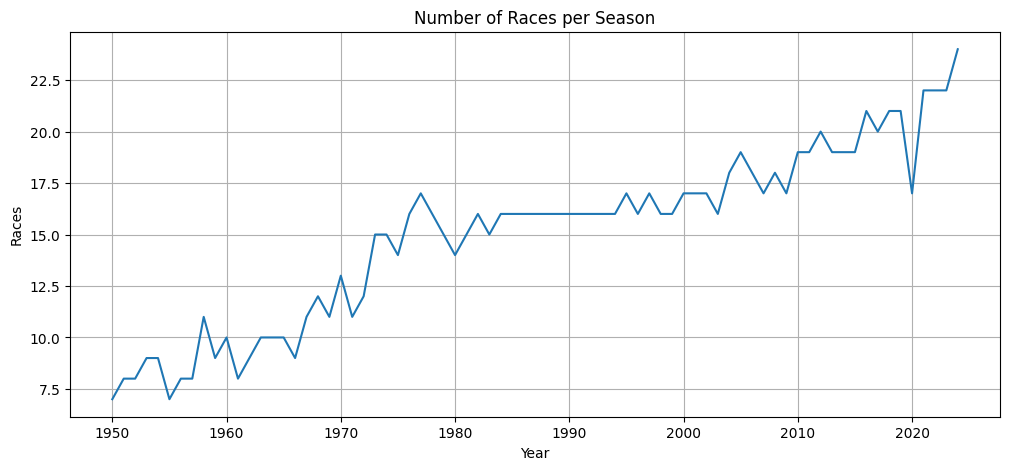

In [19]:
pdf = yearly_races.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(pdf["year"], pdf["num_races"])
plt.title("Number of Races per Season")
plt.xlabel("Year")
plt.ylabel("Races")
plt.grid(True)
plt.show()

## Driver Performance Analysis

### Top drivers by wins

In [22]:
fact_race_result = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
top_winners = fact_race_result.filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("wins")) \
    .join(
        drivers.select("driverId", "driver_name"),
        on="driverId",
        how="left"
    ) \
    .select("driver_name", "wins") \
    .orderBy(F.desc("wins"))

top_winners.show(20, truncate=False)

+------------------+----+
|driver_name       |wins|
+------------------+----+
|Lewis Hamilton    |105 |
|Michael Schumacher|91  |
|Max Verstappen    |63  |
|Sebastian Vettel  |53  |
|Alain Prost       |51  |
|Ayrton Senna      |41  |
|Fernando Alonso   |32  |
|Nigel Mansell     |31  |
|Jackie Stewart    |27  |
|Niki Lauda        |25  |
|Jim Clark         |25  |
|Juan Fangio       |24  |
|Nico Rosberg      |23  |
|Nelson Piquet     |23  |
|Damon Hill        |22  |
|Kimi Räikkönen    |21  |
|Mika Häkkinen     |20  |
|Stirling Moss     |16  |
|Jenson Button     |15  |
|Emerson Fittipaldi|14  |
+------------------+----+
only showing top 20 rows


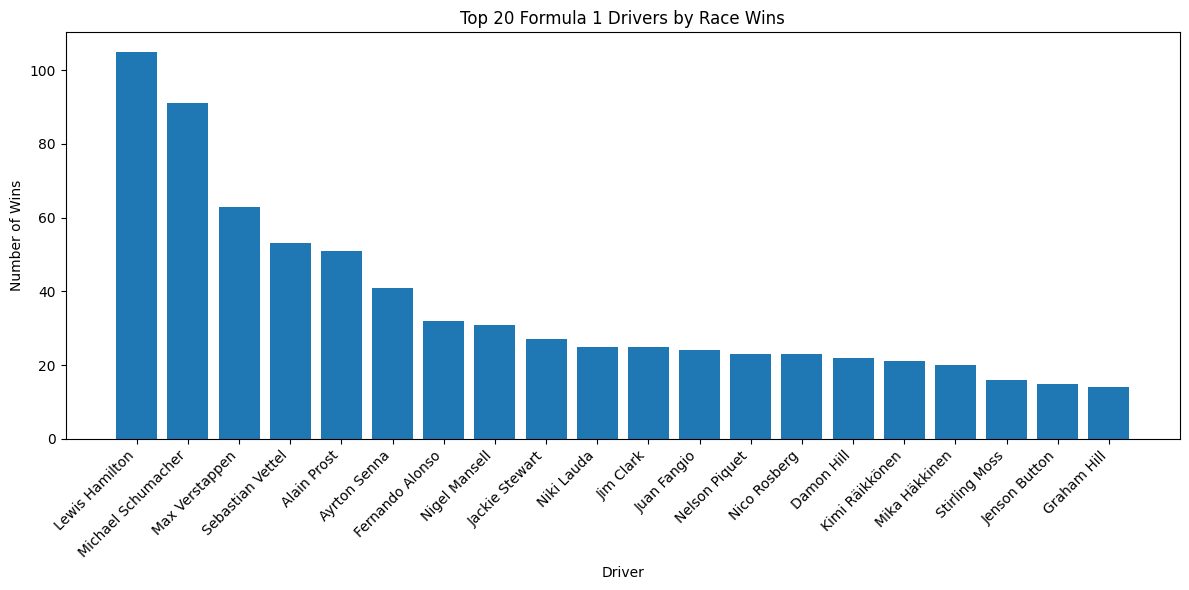

In [23]:
top_winners_pd = top_winners.limit(20).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(top_winners_pd["driver_name"], top_winners_pd["wins"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Driver")
plt.ylabel("Number of Wins")
plt.title("Top 20 Formula 1 Drivers by Race Wins")
plt.tight_layout()
plt.show()

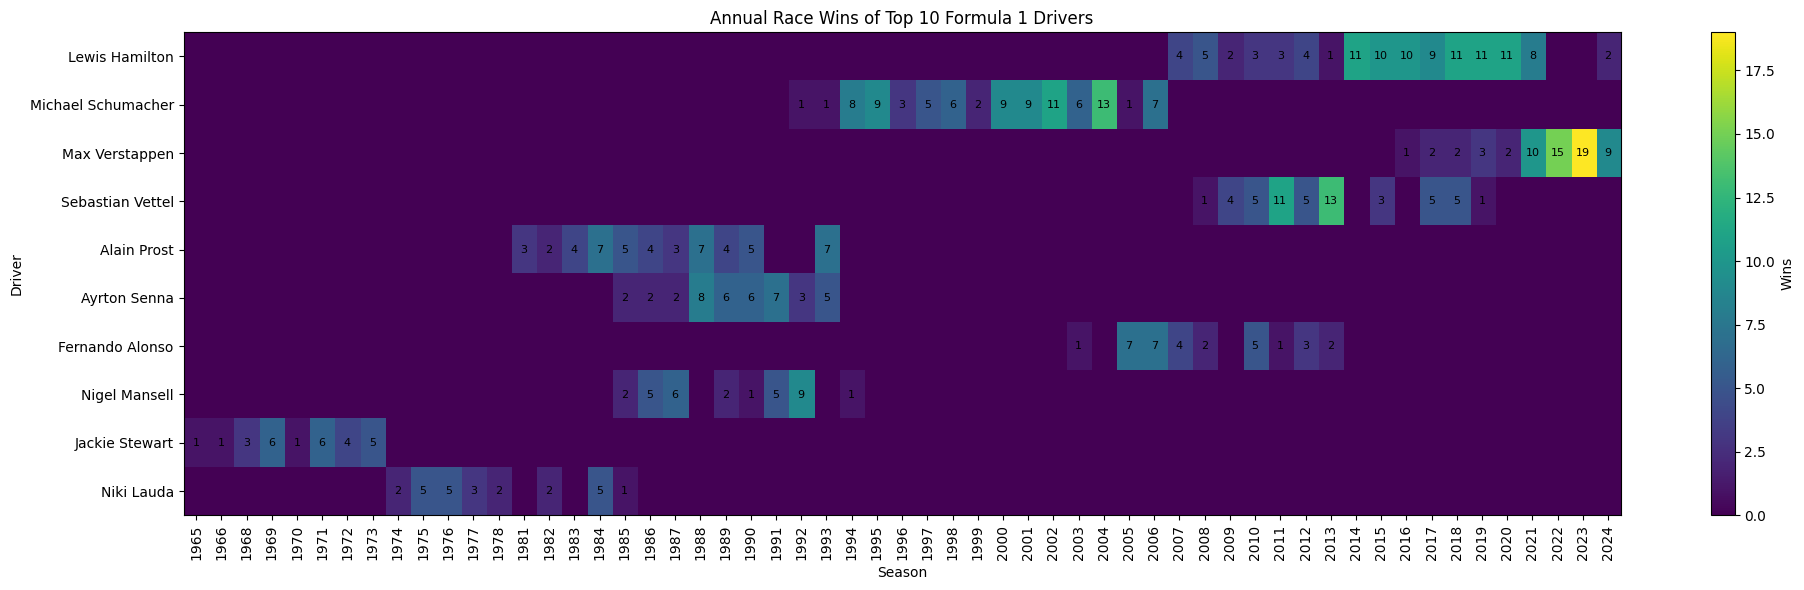

In [24]:
# Top 10 drivers by total wins
top10_drivers = fact_race_result \
    .filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("total_wins")) \
    .orderBy(F.desc("total_wins")) \
    .limit(10)

# Annual wins for those drivers
yearly_wins = fact_race_result \
    .filter(F.col("position") == 1) \
    .join(top10_drivers.select("driverId"), on="driverId") \
    .groupBy("year", "driverId") \
    .agg(F.countDistinct("raceId").alias("wins"))

# Add driver names
yearly_wins_named = yearly_wins.join(
    drivers.select("driverId", "driver_name"),
    on="driverId",
    how="left"
)

# Convert to Pandas
wins_pd = yearly_wins_named.toPandas()

# Pivot for heatmap
heatmap_data = wins_pd.pivot_table(
    index="driver_name",
    columns="year",
    values="wins",
    fill_value=0
)

# Sort drivers by total wins
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(20, 6))

im = plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Wins")

# Add numbers inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                int(value),
                ha="center",
                va="center",
                fontsize=8
            )

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.xlabel("Season")
plt.ylabel("Driver")
plt.title("Annual Race Wins of Top 10 Formula 1 Drivers")

plt.tight_layout()
plt.show()

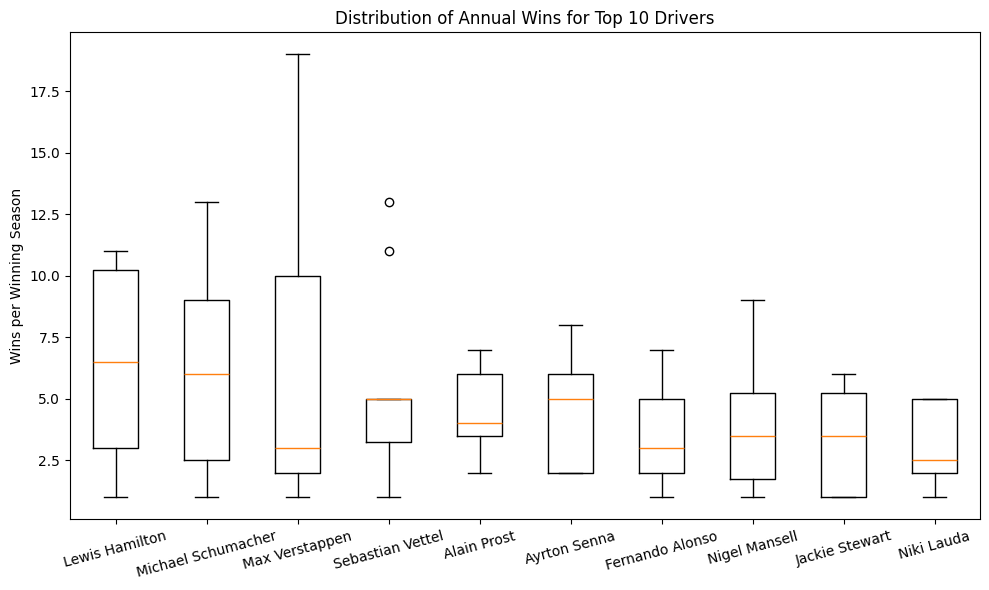

In [25]:
# Convert to pandas
wins_pd = yearly_wins_named.toPandas()

# Prepare data for boxplot
driver_order = wins_pd.groupby("driver_name")["wins"] \
    .sum() \
    .sort_values(ascending=False) \
    .index

boxplot_data = [
    wins_pd[wins_pd["driver_name"] == driver]["wins"]
    for driver in driver_order
]

# Plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=driver_order
)

plt.ylabel("Wins per Winning Season")
plt.title("Distribution of Annual Wins for Top 10 Drivers")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Distribution of Annual Wins for Top Drivers

The boxplot compares the distribution of annual race wins among the most successful Formula 1 drivers. Only seasons in which drivers achieved at least one victory were included in the analysis, allowing the comparison to focus on competitive performance rather than career length.

Several important patterns can be observed:

- **Lewis Hamilton** and **Michael Schumacher** demonstrate the highest median number of wins per successful season, indicating long-term consistency and sustained dominance across multiple years.

- **Max Verstappen** shows the largest variability in annual wins, with a very high maximum value reaching 19 wins in a single season. This reflects the exceptional level of dominance achieved during recent Red Bull seasons.

- **Sebastian Vettel** has a relatively compact distribution with several high outliers, suggesting strong peak performance concentrated in specific dominant years.

- **Ayrton Senna**, **Alain Prost**, **Fernando Alonso**, and **Nigel Mansell** exhibit more moderate distributions, reflecting strong performance with fewer exceptionally dominant seasons.

- Older-era drivers such as **Jim Clark** and **Jackie Stewart** generally have lower annual win totals. This is expected because earlier Formula 1 seasons contained significantly fewer races.

Overall, the visualizations highlight both the evolution of Formula 1 across decades and the differences in driver dominance, consistency, and peak performance.

## F1 driver-movement flow chart (2020–2024)

PySpark pipeline + Graphviz rendering.

**Layout:** years down the left, the 10 teams as colored columns on top, each
driver shown by a 3-letter code plus the season **teammate qualifying
head-to-head** (`wins-losses`, the *out-qualify score*). Solid lines = season-
to-season continuity; **dotted lines = a driver returning after a break**.

**Note on teams — RB is not Red Bull.** `Red Bull` is Red Bull Racing; `RB` is
the sister team (Toro Rosso → AlphaTauri → RB). Renamed constructors are
collapsed to one canonical column so there are exactly 10:
`Renault→Alpine`, `Racing Point→Aston Martin`, `AlphaTauri→RB`,
`Alfa Romeo→Sauber`. That is why the RB column is populated for every season
(it absorbs the AlphaTauri entries).

In [26]:
START, END = 2020, 2024

drivers = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
cons    = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")
facts   = (spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
                .filter((F.col("year") >= START) & (F.col("year") <= END)))

### Reusable functions — chart any driver(s) by name

`prepare_driver_stints(spark, gold, names)` builds the stint table for a
list of one or more driver names; `render_movements(pdf, names)` draws the
colored trails. `score="race"` uses race finishing H2H, `score="quali"`
uses qualifying H2H.

In [27]:
def prepare_driver_stints(spark, GOLD_PATH, names=None, ids=None, years=None, teams=None):
    """Every team stint for a list of 3-letter driver abbreviations, with
    qualifying and race head-to-head vs teammates.
    `abbrs`: list[str] of 3-letter codes (e.g. ["VER","HAM"]).
    `years`: optional list[int] to restrict the seasons read. -> pandas DF."""
    from pyspark.sql import functions as F
    drivers = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
    cons    = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")
    canon = (F.when(F.col("constructor_name") == "Renault",      F.lit("Alpine F1 Team"))
              .when(F.col("constructor_name") == "Racing Point", F.lit("Aston Martin"))
              .when(F.col("constructor_name") == "AlphaTauri",   F.lit("RB F1 Team"))
              .when(F.col("constructor_name") == "Alfa Romeo",   F.lit("Sauber"))
              .otherwise(F.col("constructor_name")))
    cons = cons.withColumn("team", canon)
    facts   = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
    if years:
        facts = facts.filter(F.col("year").isin(list(years)))

    family = F.element_at(F.split(F.col("driver_name"), " "), -1)
    abbr = (F.when(F.col("code").isNotNull() & (F.col("code") != "\\N"),
                   F.upper(F.substring(F.col("code"), 1, 3)))
             .otherwise(F.upper(F.substring(family, 1, 3))))
    drivers = drivers.withColumn("abbr", abbr)
    if ids:
        foc = drivers.filter(F.col("driverId").isin([int(i) for i in ids]))
    elif names:
        foc = drivers.filter(F.upper(F.col("driver_name")).isin([n.upper() for n in names]))
    else:
        foc = drivers          # no names given -> keep everyone; teams/years narrow it
    foc = foc.select("driverId", "driver_name", "abbr")

    # one row per (driver, year, team); first_round orders mid-season moves
    stints = (facts.join(F.broadcast(foc), "driverId")
        .join(cons.select("constructorId", "team"), "constructorId")
        .groupBy("driverId", "driver_name", "abbr", "year", "team")
        .agg(F.min("round").alias("first_round"), F.count("*").alias("races")))
    if teams:
        stints = stints.filter(F.col("team").isin(list(teams)))

    # qualifying head-to-head per (driver, year)
    qall = (facts.filter(F.col("qualifying_position").isNotNull())
            .select("year", "raceId", "constructorId", "driverId", "qualifying_position"))
    mq = qall.select("raceId", "constructorId", F.col("driverId").alias("mate_id"),
                     F.col("qualifying_position").alias("mate_q"))
    qh = (qall.join(mq, ["raceId", "constructorId"]).filter(F.col("driverId") != F.col("mate_id"))
          .groupBy("year", "driverId")
          .agg(F.sum(F.when(F.col("qualifying_position") < F.col("mate_q"), 1).otherwise(0)).alias("q_wins"),
               F.sum(F.when(F.col("qualifying_position") > F.col("mate_q"), 1).otherwise(0)).alias("q_losses")))

    # race head-to-head per (driver, year, team): finished ahead of best teammate?
    res = facts.select("year", "raceId", "constructorId", "driverId", "positionOrder")
    res_foc = res.join(F.broadcast(foc.select("driverId")), "driverId")
    mr = res.select("raceId", "constructorId", F.col("driverId").alias("mate_id"),
                    F.col("positionOrder").alias("mate_po"))
    rh = (res_foc.join(mr, ["raceId", "constructorId"]).filter(F.col("driverId") != F.col("mate_id"))
          .groupBy("year", "constructorId", "driverId", "raceId", "positionOrder")
          .agg(F.min("mate_po").alias("best_mate"))
          .join(cons.select("constructorId", "team"), "constructorId")
          .groupBy("year", "driverId", "team")
          .agg(F.sum(F.when(F.col("positionOrder") < F.col("best_mate"), 1).otherwise(0)).alias("r_wins"),
               F.sum(F.when(F.col("positionOrder") > F.col("best_mate"), 1).otherwise(0)).alias("r_losses")))

    stints = (stints.join(qh, ["year", "driverId"], "left").fillna(0, ["q_wins", "q_losses"])
                    .join(rh, ["year", "driverId", "team"], "left").fillna(0, ["r_wins", "r_losses"]))
    return stints.toPandas()


In [28]:
def render_movements(pdf_stints, names=None, ids=None, years=None, out_png="movements.png",
                     score="race", min_races=1, legend=False, teams=None,
                     col_w=150.0, row_h=51.0, header_fontsize=16):
    """Draw colored movement trails, one per DRIVER (keyed on driverId, so even
    drivers that share a full name or 3-letter code stay separate). Nodes are
    labelled with the 3-letter abbreviation.
    Select drivers with either `names` (full names, case-insensitive) OR `ids`
    (exact driverId values). Omit both to draw every driver in pdf_stints.
    years = optional list[int] of seasons; score = "race" or "quali"."""
    import subprocess, collections
    from IPython.display import Image, display
    PALETTE = ["#1F5FD0", "#D4341E", "#1C9E4B", "#9A3FC0", "#E08A00",
               "#0E8E8E", "#B0306A", "#555555", "#2B7A0B", "#8A5A00"]
    wkey, lkey = ("r_wins", "r_losses") if score == "race" else ("q_wins", "q_losses")
    yset = set(years) if years else None
    tset = set(teams) if teams else None

    # map driverId -> (name, abbr) and a name lookup for selection
    id_name, id_abbr = {}, {}
    name_to_ids = collections.defaultdict(list)
    for r in pdf_stints.itertuples():
        did = int(r.driverId)
        id_name[did] = r.driver_name; id_abbr[did] = r.abbr
        if did not in name_to_ids[r.driver_name.lower()]:
            name_to_ids[r.driver_name.lower()].append(did)

    if ids:                                            # exact driverIds win
        order = [int(i) for i in ids if int(i) in id_name]
    elif names:                                        # full names, case-insensitive
        order = []
        for nm in names:
            for did in name_to_ids.get(nm.lower(), []):
                if did not in order: order.append(did)
    else:                                              # everyone, first-seen order
        order = list(dict.fromkeys(int(r.driverId) for r in pdf_stints.itertuples()))
    if not order:
        raise ValueError("none of the requested drivers are in the data")
    color = {did: PALETTE[i % len(PALETTE)] for i, did in enumerate(order)}

    seq = collections.defaultdict(list)
    for r in pdf_stints.itertuples():
        did = int(r.driverId)
        if did not in color:
            continue
        if yset and int(r.year) not in yset:
            continue
        if int(r.races) < min_races:
            continue
        if tset and r.team not in tset:
            continue
        seq[did].append((int(r.year), int(r.first_round), r.team,
                         int(getattr(r, wkey)), int(getattr(r, lkey))))
    for k in seq: seq[k].sort()

    present = []
    for did in order:
        for (y, fr, t, w, l) in seq.get(did, []):
            if t not in present: present.append(t)
    teams = [t for t in teams if t in present] if teams else present
    yrs = sorted({y for did in seq for (y, fr, t, w, l) in seq[did]})
    if not yrs:
        raise ValueError("no stints found for the requested drivers")
    colx = {t: i for i, t in enumerate(teams)}
    rowy = {y: i for i, y in enumerate(yrs)}
    nid = lambda did, y, t: "n_%d_%d_%d" % (order.index(did), y, colx[t])

    # fan out drivers sharing the same (year, team) cell
    cell_members = collections.defaultdict(list)
    for did in order:
        for (y, fr, t, w, l) in seq.get(did, []):
            if did not in cell_members[(y, t)]:
                cell_members[(y, t)].append(did)
    sub_w = 34.0
    node_x = {}
    for (y, t), mem in cell_members.items():
        n = len(mem)
        for j, did in enumerate(mem):
            node_x[(did, y, t)] = colx[t] * col_w + (j - (n - 1) / 2.0) * sub_w

    dot = ['digraph M {', '  graph [bgcolor="#FFFFFF"];',
           '  node [shape=box, style="filled,rounded", fontname="Helvetica-Bold", '
           'fontsize=11, fixedsize=true, width=0.7, height=0.42];',
           '  edge [penwidth=2.4, arrowsize=0.6];']
    for t in teams:
        dot.append(f'  h_{colx[t]} [pos="{colx[t]*col_w:.1f},{row_h*0.9:.1f}", label="{t}", '
                   f'shape=box, style=filled, fillcolor="#E8E8E8", fontcolor="#222222", '
                   f'fontsize={header_fontsize}, width=1.95, height=0.6];')
    for y in yrs:
        dot.append(f'  y_{y} [pos="{-col_w*0.8:.1f},{-rowy[y]*row_h:.1f}", label="{y}", '
                   f'shape=plaintext, fontsize=13, fontcolor="#333333", fixedsize=false];')
    for did in order:
        col = color[did]; ab = id_abbr.get(did, "")
        for (y, fr, t, w, l) in seq.get(did, []):
            sc = f'<BR/><FONT POINT-SIZE="8">{w}-{l}</FONT>' if (w + l) > 0 else ''
            dot.append(f'  {nid(did,y,t)} [pos="{node_x[(did,y,t)]:.1f},{-rowy[y]*row_h:.1f}", '
                       f'label=<{ab}{sc}>, fillcolor="{col}", fontcolor="#FFFFFF"];')
    for did in order:
        s = seq.get(did, []); col = color[did]
        for (y1, f1, t1, w1, l1), (y2, f2, t2, w2, l2) in zip(s, s[1:]):
            style = "dotted" if (y2 - y1) > 1 else "solid"
            extra = ", penwidth=3.0" if style == "dotted" else ""
            dot.append(f'  {nid(did,y1,t1)} -> {nid(did,y2,t2)} [color="{col}", style={style}{extra}];')
    if legend:
        ly = -(len(yrs) + 1) * row_h * 0.55
        for i, did in enumerate(order):
            dot.append(f'  lg_{i} [pos="{0.6*col_w:.1f},{ly - i*46:.1f}", '
                       f'label="{id_abbr.get(did,"")}  {id_name.get(did,"")}", '
                       f'shape=box, style=filled, fillcolor="{color[did]}", fontcolor="#FFFFFF", '
                       f'fontsize=11, width=2.6, height=0.4];')
        dot.append(f'  lg_note [pos="{0.6*col_w:.1f},{ly - len(order)*46:.1f}", '
                   f'label="solid = next stint / season   dotted = return after a gap year   '
                   f'(score = {score} H2H vs teammate)", '
                   f'shape=plaintext, fontsize=10, fontcolor="#333333", fixedsize=false];')

    dot.append('}')
    open(out_png + ".dot", "w").write("\n".join(dot))
    subprocess.run(["neato", "-n2", "-Tpng", "-Gdpi=150", out_png + ".dot", "-o", out_png], check=True)
    display(Image(out_png))
    return out_png


### Cluster statistics

A *cluster* is a set of drivers (given by 3-letter abbreviations). These functions summarise the cluster across the teams its members raced for, with totals **and** per-start rates so teams of different size/era are comparable. Omit `abbrs` to include every driver for the chosen `teams`/`years`.

In [31]:
# ===== Section 7: cluster statistics (cluster = list of 3-letter abbreviations) =====
def _cluster_base(spark, GOLD_PATH, names=None, ids=None, years=None, teams=None):
    """Shared base: race results of the cluster's drivers with canonical team
    names. Returns (base, facts_team): `base` = cluster rows; `facts_team` = all
    drivers (needed for teammate comparisons)."""
    from pyspark.sql import functions as F
    drivers = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
    cons    = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")
    facts   = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
    if years:
        facts = facts.filter(F.col("year").isin(list(years)))
    canon = (F.when(F.col("constructor_name") == "Renault",      F.lit("Alpine F1 Team"))
              .when(F.col("constructor_name") == "Racing Point", F.lit("Aston Martin"))
              .when(F.col("constructor_name") == "AlphaTauri",   F.lit("RB F1 Team"))
              .when(F.col("constructor_name") == "Alfa Romeo",   F.lit("Sauber"))
              .otherwise(F.col("constructor_name")))
    cons = cons.withColumn("team", canon)
    family = F.element_at(F.split(F.col("driver_name"), " "), -1)
    abbr = (F.when(F.col("code").isNotNull() & (F.col("code") != "\\N"),
                   F.upper(F.substring(F.col("code"), 1, 3)))
             .otherwise(F.upper(F.substring(family, 1, 3))))
    drivers = drivers.withColumn("abbr", abbr)
    if ids:
        foc = drivers.filter(F.col("driverId").isin([int(i) for i in ids]))
    elif names:
        foc = drivers.filter(F.upper(F.col("driver_name")).isin([n.upper() for n in names]))
    else:
        foc = drivers
    foc = foc.select("driverId", "driver_name", "abbr")
    facts_team = facts.join(cons.select("constructorId", "team"), "constructorId")
    base = facts_team.join(F.broadcast(foc), "driverId")
    if teams:
        base = base.filter(F.col("team").isin(list(teams)))
    return base, facts_team


def cluster_team_summary(spark, GOLD_PATH, names=None, ids=None, years=None, teams=None, add_totals=True):
    """One comparable row per team the cluster raced for. Totals AND per-start
    rates so teams of different size/era can be compared. -> pandas DF."""
    from pyspark.sql import functions as F
    base, facts_team = _cluster_base(spark, GOLD_PATH, names, ids, years, teams)

    # teammate qualifying H2H (vs same-constructor cars, any driver)
    mq = facts_team.filter(F.col("qualifying_position").isNotNull()).select(
            "raceId", "constructorId", F.col("driverId").alias("mid"),
            F.col("qualifying_position").alias("mqp"))
    qj = (base.filter(F.col("qualifying_position").isNotNull())
              .join(mq, ["raceId", "constructorId"]).filter(F.col("driverId") != F.col("mid")))
    qh = qj.groupBy("team").agg(
        F.sum(F.when(F.col("qualifying_position") < F.col("mqp"), 1).otherwise(0)).alias("q_wins"),
        F.sum(F.when(F.col("qualifying_position") > F.col("mqp"), 1).otherwise(0)).alias("q_losses"))

    # teammate race H2H (finished ahead of best teammate)
    mr = facts_team.select("raceId", "constructorId", F.col("driverId").alias("mid"),
                           F.col("positionOrder").alias("mpo"))
    rj = (base.join(mr, ["raceId", "constructorId"]).filter(F.col("driverId") != F.col("mid"))
              .groupBy("team", "raceId", "driverId", "positionOrder")
              .agg(F.min("mpo").alias("best")))
    rh = rj.groupBy("team").agg(
        F.sum(F.when(F.col("positionOrder") < F.col("best"), 1).otherwise(0)).alias("r_wins"),
        F.sum(F.when(F.col("positionOrder") > F.col("best"), 1).otherwise(0)).alias("r_losses"))

    agg = base.groupBy("team").agg(
        F.countDistinct("driverId").alias("drivers"),
        F.countDistinct(F.concat_ws("_", "year", "driverId")).alias("driver_seasons"),
        F.count("*").alias("starts"),
        F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("wins"),
        F.sum(F.when(F.col("positionOrder") <= 3, 1).otherwise(0)).alias("podiums"),
        F.sum(F.coalesce(F.col("points"), F.lit(0))).alias("points"),
        F.avg("positionOrder").alias("avg_finish"),
        F.avg("qualifying_position").alias("avg_grid"))

    out = (agg.join(qh, "team", "left").join(rh, "team", "left")
              .fillna(0, ["q_wins", "q_losses", "r_wins", "r_losses"])
              .withColumn("win_pct",          F.round(100 * F.col("wins")    / F.col("starts"), 2))
              .withColumn("podium_pct",       F.round(100 * F.col("podiums") / F.col("starts"), 2))
              .withColumn("points_per_start", F.round(F.col("points") / F.col("starts"), 3))
              .withColumn("avg_finish",       F.round("avg_finish", 2))
              .withColumn("avg_grid",         F.round("avg_grid", 2))
              .withColumn("quali_h2h", F.concat_ws("-", "q_wins", "q_losses"))
              .withColumn("race_h2h",  F.concat_ws("-", "r_wins", "r_losses")))
    cols = ["team", "drivers", "driver_seasons", "starts", "wins", "podiums", "points",
            "win_pct", "podium_pct", "points_per_start", "avg_finish", "avg_grid",
            "quali_h2h", "race_h2h"]
    pdf = out.select(cols).orderBy(F.desc("points_per_start")).toPandas()

    if add_totals:
        # cluster-wide totals (distinct drivers, not a sum across teams)
        ov = base.agg(
            F.countDistinct("driverId").alias("drivers"),
            F.countDistinct(F.concat_ws("_", "year", "driverId")).alias("driver_seasons"),
            F.count("*").alias("starts"),
            F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("wins"),
            F.sum(F.when(F.col("positionOrder") <= 3, 1).otherwise(0)).alias("podiums"),
            F.sum(F.coalesce(F.col("points"), F.lit(0))).alias("points"),
            F.avg("positionOrder").alias("avg_finish"),
            F.avg("qualifying_position").alias("avg_grid")).collect()[0]
        qov = qj.agg(
            F.sum(F.when(F.col("qualifying_position") < F.col("mqp"), 1).otherwise(0)).alias("w"),
            F.sum(F.when(F.col("qualifying_position") > F.col("mqp"), 1).otherwise(0)).alias("l")).collect()[0]
        rov = rj.agg(
            F.sum(F.when(F.col("positionOrder") < F.col("best"), 1).otherwise(0)).alias("w"),
            F.sum(F.when(F.col("positionOrder") > F.col("best"), 1).otherwise(0)).alias("l")).collect()[0]
        import pandas as pd
        st = pdf["starts"].sum()                       # total cluster starts
        def wavg(col, nd):                             # starts-weighted mean of team rows
            return round((pdf[col] * pdf["starts"]).sum() / st, nd) if st else 0.0
        total = {
            "team": "ALL (cluster)",
            "drivers": ov["drivers"], "driver_seasons": ov["driver_seasons"],
            "starts": int(st),
            "wins": int(pdf["wins"].sum()), "podiums": int(pdf["podiums"].sum()),
            "points": pdf["points"].sum(),
            "win_pct":          wavg("win_pct", 2),          # = Σ(win_pct_i * starts_i)/Σstarts
            "podium_pct":       wavg("podium_pct", 2),
            "points_per_start": wavg("points_per_start", 3),
            "avg_finish":       wavg("avg_finish", 2),
            "avg_grid":         wavg("avg_grid", 2),
            "quali_h2h": f"{qov['w']}-{qov['l']}",
            "race_h2h":  f"{rov['w']}-{rov['l']}"}
        pdf = pd.concat([pdf, pd.DataFrame([total])], ignore_index=True)
    return pdf


In [32]:
def cluster_bar(summary_pdf, metric="points_per_start", out_png="cluster_bar.png"):
    """Horizontal bar chart of one summary metric per team (sorted)."""
    import matplotlib; matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from IPython.display import Image, display
    d = summary_pdf.sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(2.2, 0.45 * len(d))))
    ax.barh(d["team"].astype(str), d[metric], color="#1F5FD0")
    ax.set_xlabel(metric)
    ax.set_title(f"Cluster — {metric} by team")
    for i, v in enumerate(d[metric]):
        ax.text(v, i, f" {v:g}", va="center", fontsize=9)
    fig.tight_layout(); fig.savefig(out_png, dpi=100); plt.close(fig)
    display(Image(out_png)); return out_png


In [33]:
def cluster_heatmap(spark, GOLD_PATH, names=None, ids=None, years=None, teams=None,
                    metric="drivers", out_png="cluster_heatmap.png"):
    """Heatmap of teams (rows) x years (cols) for the cluster.
    metric = "drivers" (distinct cluster drivers), "points_per_start", or "wins"."""
    from pyspark.sql import functions as F
    import numpy as np
    base, _ = _cluster_base(spark, GOLD_PATH, names, ids, years, teams)
    if metric == "drivers":
        g = base.groupBy("team", "year").agg(F.countDistinct("driverId").alias("v"))
    elif metric == "points_per_start":
        g = base.groupBy("team", "year").agg(
            F.round(F.sum(F.coalesce(F.col("points"), F.lit(0))) / F.count("*"), 2).alias("v"))
    elif metric == "wins":
        g = base.groupBy("team", "year").agg(
            F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("v"))
    else:
        raise ValueError("metric must be 'drivers', 'points_per_start' or 'wins'")
    pdf = g.toPandas()
    mat = pdf.pivot(index="team", columns="year", values="v").sort_index()
    mat = mat.reindex(sorted(mat.columns), axis=1)

    import matplotlib; matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from IPython.display import Image, display
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * mat.shape[1] + 2),
                                    max(3, 0.5 * mat.shape[0] + 1)))
    im = ax.imshow(mat.values.astype(float), aspect="auto", cmap="viridis")
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if v == v:  # not NaN
                ax.text(j, i, f"{v:g}", ha="center", va="center", color="white", fontsize=7)
    fig.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Cluster {metric}: team x year")
    fig.tight_layout(); fig.savefig(out_png, dpi=100); plt.close(fig)
    display(Image(out_png)); return out_png


,team,drivers,driver_seasons,starts,wins,podiums,points,win_pct,podium_pct,points_per_start,avg_finish,avg_grid,quali_h2h,race_h2h
0,Red Bull,1,7,149,60,101,2491.5,40.27,67.79,16.721,4.28,3.64,132-17,123-26
1,Mercedes,2,11,229,50,130,3225.5,21.83,56.77,14.085,4.76,4.01,110-119,115-114
2,Sauber,1,3,68,0,0,57.0,0.00,0.00,0.838,14.01,13.63,51-17,42-26
3,ALL (cluster),3,21,446,110,231,5774.0,24.66,51.80,12.946,6.01,5.35,293-153,280-166


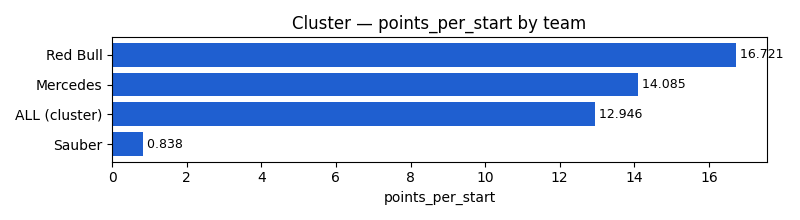

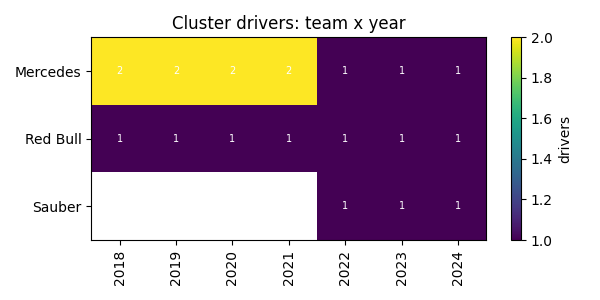

'cluster_heatmap.png'

In [34]:
# Example: describe a cluster given by driver abbreviations
cluster = ["Lewis Hamilton", "Valtteri Bottas", "Max Verstappen"]
yrs = list(range(2018, 2025))

summary = cluster_team_summary(spark, GOLD_PATH, cluster, years=yrs)
display(summary)                                   # comparable team table

cluster_bar(summary, metric="points_per_start")    # compare teams on one rate
cluster_heatmap(spark, GOLD_PATH, cluster, years=yrs, metric="drivers")


### Combined: `describe_cluster(...)` with output flags

Toggle each output: `show_table`, `show_bar`, `show_heatmap`. Pick which metric the bar (`bar_metric`) and heatmap (`heatmap_metric`) use.

In [35]:
def describe_cluster(spark, GOLD_PATH, names=None, ids=None, years=None, teams=None,
                     show_flow=True, show_table=False, show_bar=False, show_heatmap=False,
                     bar_metric="points_per_start", heatmap_metric="drivers",
                     min_races=1, legend=False):
    """One call to describe a cluster. By default shows ONLY the flow chart;
    turn on the others with show_table / show_bar / show_heatmap.
    The table is displayed (not returned) to avoid showing it twice;
    use cluster_team_summary(...) directly if you need the DataFrame."""
    from IPython.display import display
    if show_flow:
        pdf = prepare_driver_stints(spark, GOLD_PATH, names, ids, years, teams)
        render_movements(pdf, names=names, ids=ids, years=years, teams=teams,
                         min_races=min_races, legend=legend)
    summary = None
    if show_table or show_bar:
        summary = cluster_team_summary(spark, GOLD_PATH, names, ids, years, teams)
    if show_table:
        display(summary)
    if show_bar:
        cluster_bar(summary, metric=bar_metric)
    if show_heatmap:
        cluster_heatmap(spark, GOLD_PATH, names, ids, years, teams, metric=heatmap_metric)
    return None


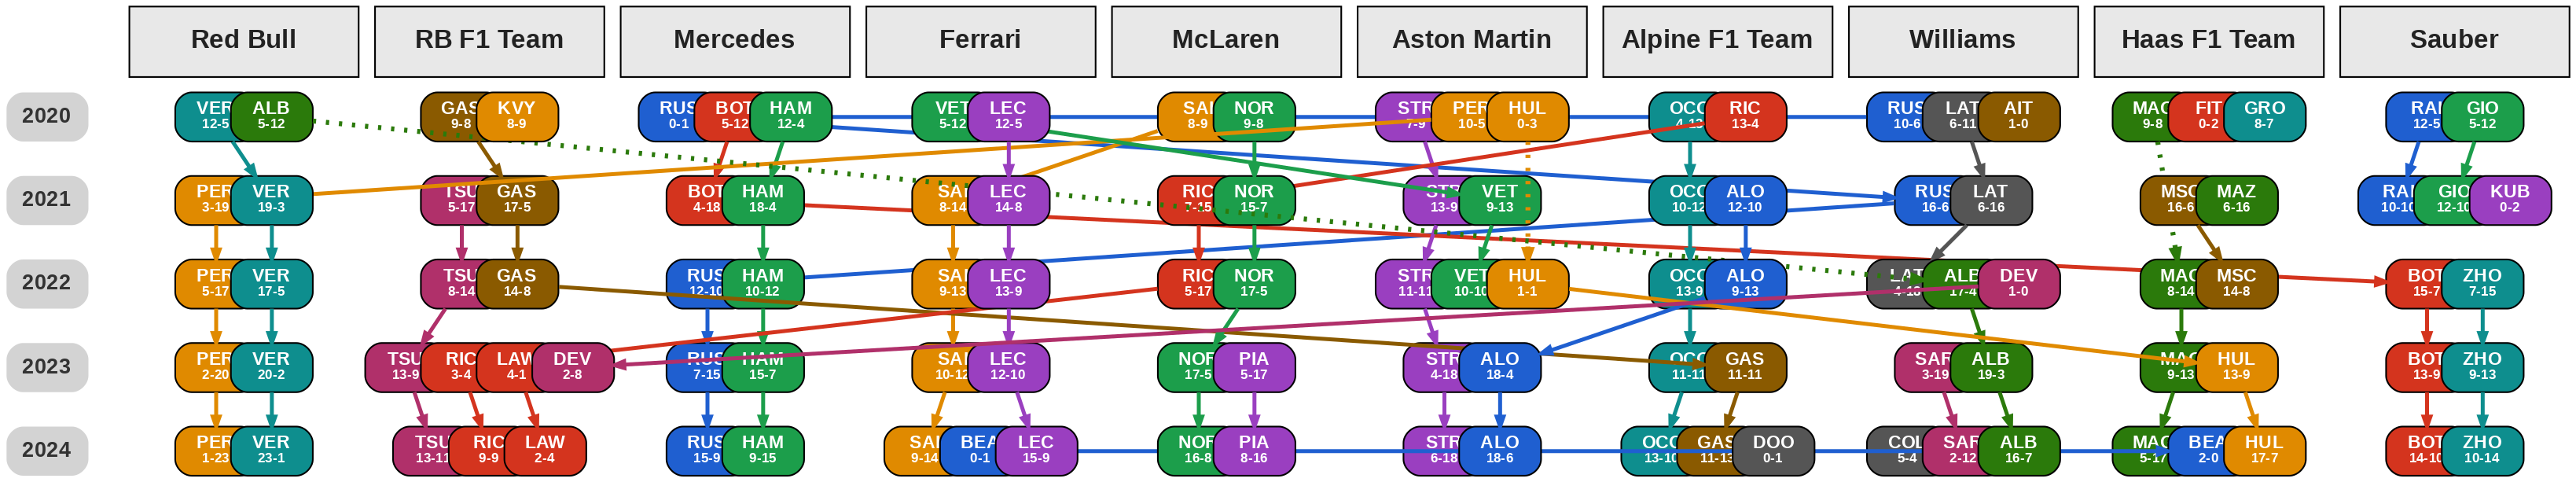

,team,drivers,driver_seasons,starts,wins,podiums,points,win_pct,podium_pct,points_per_start,avg_finish,avg_grid,quali_h2h,race_h2h
0,Red Bull,3,10,214,60,112,2948.5,28.04,52.34,13.778,5.56,5.16,107-107,107-107
1,Mercedes,3,11,214,27,87,2479.5,12.62,40.65,11.586,5.85,5.10,107-107,107-107
2,Ferrari,4,11,214,10,59,1930.5,4.67,27.57,9.021,7.31,6.10,107-107,107-107
3,McLaren,4,10,214,7,38,1501.0,3.27,17.76,7.014,8.16,7.91,107-107,107-107
4,Aston Martin,5,12,214,1,13,702.0,0.47,6.07,3.280,10.85,11.56,107-107,107-107
5,Alpine F1 Team,5,11,214,1,9,679.0,0.47,4.21,3.173,10.86,11.04,107-107,107-107
6,RB F1 Team,6,13,214,1,2,346.0,0.47,0.93,1.617,12.58,12.16,107-107,107-107
7,Haas F1 Team,7,12,214,0,0,96.0,0.00,0.00,0.449,14.90,15.06,106-106,107-107
8,Sauber,5,11,214,0,0,94.0,0.00,0.00,0.439,14.02,15.23,107-107,107-107
9,Williams,7,13,213,0,1,74.0,0.00,0.47,0.347,14.90,15.62,106-106,106-106


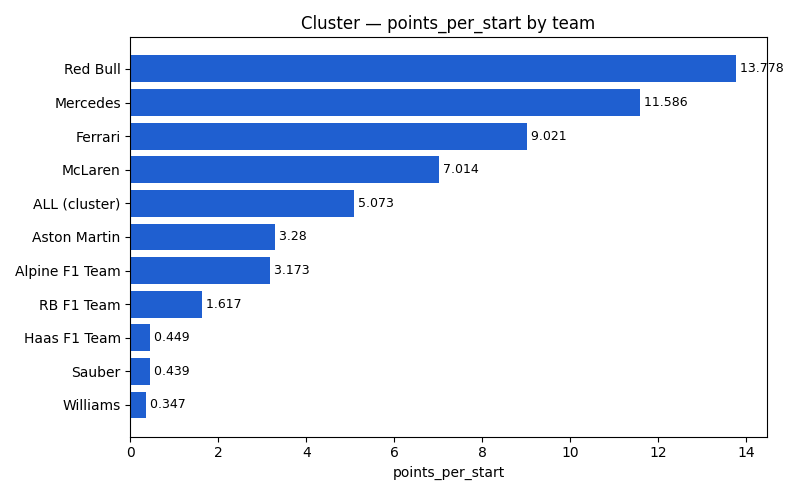

In [36]:
# default: flow chart only
#cluster = ["HAM", "BOT", "VER", "PER", "LEC", "SAI", "NOR", "RIC"]
teams=['Red Bull', 'RB F1 Team', 'Mercedes', 'Ferrari', 'McLaren', 'Aston Martin', 'Alpine F1 Team', 'Williams', 'Haas F1 Team', 'Sauber']
yrs = list(range(2020, 2025))
describe_cluster(spark, GOLD_PATH, years=yrs, teams=teams, show_table=True, show_bar=True)

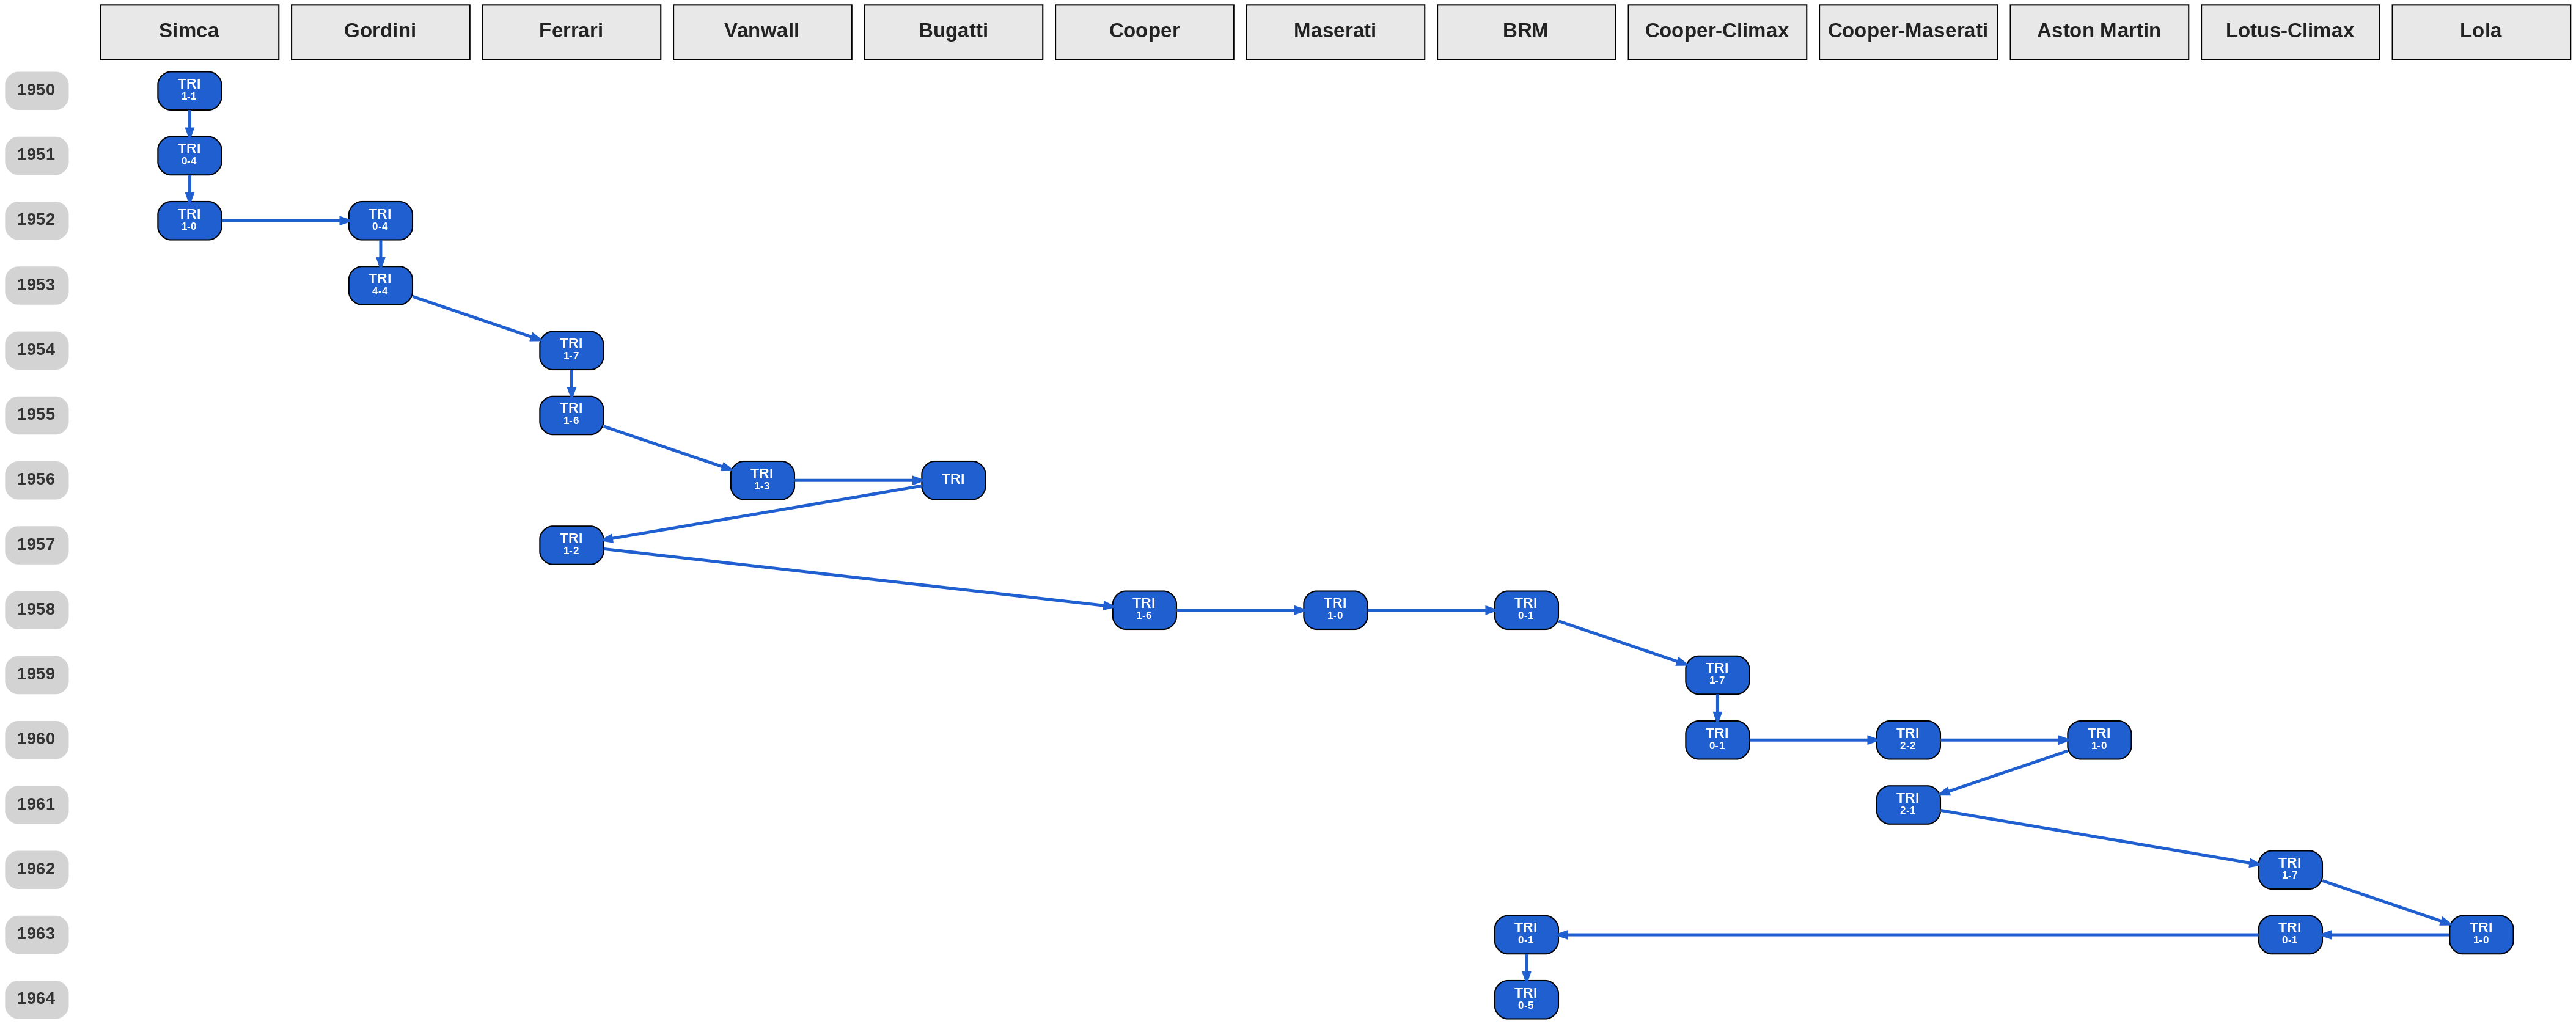

In [37]:
cluster = ["Maurice Trintignant"]
describe_cluster(spark, GOLD_PATH, cluster)